In [ ]:
"""
======================
State estimation for an n-link pendulum network with sparse sensor corruption.

Solves:
    min_{x, b}  (1/2 sigma_w^2) * sum ||x_{k+1} - f(x_k)||^2
              + (1/2 sigma_v^2) * sum ||y_k - H*x_k - b||^2
              + lambda * ||b||_1

Two solvers:
  * OSQP  -- Sequential Convex Programming (SCP) with adaptive trust weight
  * IPOPT -- Exact nonlinear solve via CasADi, warm-started from OSQP solution

Design decisions
----------------
1. SCP initialised at x=0 (near the true stable equilibrium), not from y,
   because y contains the sensor corruption and would place the linearisation
   at a false equilibrium.

2. Trust weight decays geometrically each SCP iteration.  A large initial
   value stabilises the first step (the linearisation is least accurate here);
   near convergence the proximal term vanishes so it cannot bias the final
   state estimate.

3. IPOPT is warm-started from the OSQP solution, not from zeros.  The exact
   nonlinear objective is non-convex (sin terms), so starting far from the
   true solution lets IPOPT settle in a spurious local minimum.  The OSQP
   solution is already close to the truth; IPOPT then only needs to correct
   the linearisation error.

4. CVXPY Problem is built once with cp.Parameter objects so OSQP genuinely
   warm-starts across SCP iterations.

5. "sb":"yes" (suppress IPOPT banner) must sit inside the "ipopt":{} sub-dict,
   not at the top-level Opti solver options dict.
"""

from __future__ import annotations

from typing import Optional, Tuple

import numpy as np
import cvxpy as cp

try:
    import casadi as ca
    _CASADI_AVAILABLE = True
except ImportError:
    ca = None
    _CASADI_AVAILABLE = False


# =============================================================================
# 1.  Model construction
# =============================================================================

def make_measurement_matrix(n_links: int = 6, p_meas: int = 3) -> np.ndarray:
    """
    Build the (p_meas x 2*n_links) measurement matrix H.
    We observe the first p_meas joint angles only.
    """
    if p_meas > n_links:
        raise ValueError(f"p_meas ({p_meas}) must be <= n_links ({n_links}).")
    H = np.zeros((p_meas, 2 * n_links))
    H[:p_meas, :p_meas] = np.eye(p_meas)
    return H


def make_laplacian(n_links: int = 6) -> np.ndarray:
    """
    Tridiagonal diffusion / coupling matrix for the angle subsystem.
    Interior rows: [... 1 -2 1 ...]   Boundary rows: [-1 1 ...] / [... 1 -1]
    """
    L = np.zeros((n_links, n_links))
    for i in range(n_links):
        if i == 0:
            L[i, i]     = -1.0;  L[i, i + 1] =  1.0
        elif i == n_links - 1:
            L[i, i - 1] =  1.0;  L[i, i]     = -1.0
        else:
            L[i, i - 1] =  1.0;  L[i, i] = -2.0;  L[i, i + 1] = 1.0
    return L


# =============================================================================
# 2.  Nonlinear dynamics (NumPy)
# =============================================================================

def pendulum_step(
    x: np.ndarray,
    dt: float = 0.05,
    a: float = 1.0,
    d: float = 0.4,
    c: float = 0.15,
    L: Optional[np.ndarray] = None,
) -> np.ndarray:
    """
    One discrete step:
        theta_{k+1} = theta_k + dt * omega_k
        omega_{k+1} = omega_k + dt*(-a*sin(theta_k) - d*omega_k + c*L*theta_k)
    """
    n = x.size // 2
    if L is None:
        L = make_laplacian(n)
    theta, omega = x[:n], x[n:]
    return np.concatenate([
        theta + dt * omega,
        omega + dt * (-a * np.sin(theta) - d * omega + c * (L @ theta)),
    ])


def pendulum_step_jacobian(
    x: np.ndarray,
    dt: float = 0.05,
    a: float = 1.0,
    d: float = 0.4,
    c: float = 0.15,
    L: Optional[np.ndarray] = None,
) -> np.ndarray:
    """
    Analytical Jacobian df/dx.  Block structure (each block n x n):
        [ I                              dt*I          ]
        [ dt*(-a*diag(cos theta) + c*L)  (1-dt*d)*I   ]
    """
    n = x.size // 2
    if L is None:
        L = make_laplacian(n)
    theta = x[:n]
    I = np.eye(n)
    J = np.zeros((2 * n, 2 * n))
    J[:n, :n] = I
    J[:n, n:] = dt * I
    J[n:, :n] = dt * (-a * np.diag(np.cos(theta)) + c * L)
    J[n:, n:] = (1.0 - dt * d) * I
    return J


# =============================================================================
# 3.  Simulation
# =============================================================================

def simulate_pendulum_system(
    T: int = 80,
    sigma_w: float = 0.02,
    sigma_v: float = 0.02,
    s: int = 2,
    corruption_mag: float = 5.0,
    n_links: int = 6,
    p_meas: int = 3,
    dt: float = 0.05,
    a: float = 1.0,
    d: float = 0.4,
    c: float = 0.15,
    seed: Optional[int] = None,
) -> Tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    """
    Simulate with constant sparse sensor corruption  y_k = H*x_k + b_true + v_k.

    Returns: x_true (T,2n), y (T,p), b_true (p,), corrupted (s,), H (p,2n)
    """
    if p_meas > n_links:
        raise ValueError(f"p_meas ({p_meas}) must be <= n_links ({n_links}).")
    if s > p_meas:
        raise ValueError(f"s ({s}) cannot exceed p_meas ({p_meas}).")

    rng = np.random.default_rng(seed)
    n   = 2 * n_links
    H   = make_measurement_matrix(n_links=n_links, p_meas=p_meas)
    L   = make_laplacian(n_links)

    x_true    = np.zeros((T, n))
    x_true[0] = 0.25 * rng.standard_normal(n)

    w = sigma_w * rng.standard_normal((T - 1, n))

    b_true            = np.zeros(p_meas)
    corrupted         = rng.choice(p_meas, size=s, replace=False)
    b_true[corrupted] = corruption_mag * rng.standard_normal(s)

    for k in range(T - 1):
        x_true[k + 1] = pendulum_step(x_true[k], dt=dt, a=a, d=d, c=c, L=L) + w[k]

    v = sigma_v * rng.standard_normal((T, p_meas))
    y = (H @ x_true.T).T + b_true[None, :] + v

    return x_true, y, b_true, corrupted, H


# =============================================================================
# 4.  Initialisation
# =============================================================================

def initial_guess_zeros(T: int, n_links: int = 6) -> np.ndarray:
    """
    All-zero initial trajectory  (T x 2*n_links).

    NOT initialised from y because y contains the sensor corruption b.
    Setting x_init[:, i] = y[:, i] places the SCP linearisation at a false
    equilibrium (e.g. theta_0 ~ -3.72 vs true ~ 0.05), causing the SCP to
    converge to the wrong local minimum.  The system starts near the origin,
    so zeros is a much better starting point.
    """
    return np.zeros((T, 2 * n_links))


# =============================================================================
# 5.  OSQP solver via SCP with adaptive (decaying) trust weight
# =============================================================================

def estimate_osqp_scp(
    y: np.ndarray,
    H: np.ndarray,
    x_init: np.ndarray,
    sigma_w: float,
    sigma_v: float,
    n_links: int = 6,
    dt: float = 0.05,
    a: float = 1.0,
    d: float = 0.4,
    c: float = 0.15,
    lam: float = 1.0,
    trust_weight_init: float = 1e-2,
    trust_decay: float = 0.5,
    max_scp_iters: int = 20,
    tol: float = 1e-6,
    verbose: bool = False,
) -> Tuple[np.ndarray, np.ndarray, Optional[float]]:
    """
    Solve the estimation problem via SCP + OSQP.
    # cost=dynamics+measurement+λ∥b∥1​+trust_weight⋅∥X−Xbar​∥2

    Trust weight schedule
    ---------------------
    trust_weight decays as  trust_weight_init * trust_decay^it  each iteration.

    * Large initial value: proximal term dominates in iteration 0, where the
      linearisation is least accurate.  This prevents the first QP from jumping
      far outside the region where f(x) ~ f(x_bar) + J*(x-x_bar) is valid.

    * Geometric decay: by the time the SCP is close to convergence the proximal
      coefficient is effectively zero, so it no longer biases the state estimate
      toward x_bar.  Without this, a fixed positive trust_weight permanently
      pulls x toward the previous iterate even after the SCP has converged,
      inflating the state estimation error.

    The CVXPY Problem is built once with cp.Parameter objects so OSQP genuinely
    warm-starts between iterations.

    Returns
    -------
    x_est   : (T, 2*n_links) estimated state trajectory
    b_est   : (p_meas,)      estimated sensor bias
    obj_val : final objective value
    """
    T, p = y.shape
    n    = 2 * n_links
    L    = make_laplacian(n_links)

    eps_w = max(sigma_w ** 2, 1e-8)
    eps_v = max(sigma_v ** 2, 1e-8)

    # ------------------------------------------------------------------
    # Build the CVXPY problem once
    # ------------------------------------------------------------------
    X = cp.Variable((T, n), name="X")
    b = cp.Variable(p,      name="b")
    t = cp.Variable(p,      name="t", nonneg=True)   # L1 slack  t >= |b|

    x_bar_param  = cp.Parameter((T, n),  name="x_bar")
    trust_param  = cp.Parameter(nonneg=True, name="trust_w")
    f_params     = [cp.Parameter(n,      name=f"f_{k}") for k in range(T - 1)]
    J_params     = [cp.Parameter((n, n), name=f"J_{k}") for k in range(T - 1)]

    cost = cp.Constant(0)

    for k in range(T - 1):
        lin = f_params[k] + J_params[k] @ (X[k] - x_bar_param[k])
        cost = cost + (0.5 / eps_w) * cp.sum_squares(X[k + 1] - lin)

    for k in range(T):
        cost = cost + (0.5 / eps_v) * cp.sum_squares(y[k] - H @ X[k] - b)

    # Proximal / trust-region term (coefficient updated each iteration)
    cost = cost + trust_param * cp.sum_squares(X - x_bar_param)

    # L1 penalty on bias via epigraph
    cost = cost + lam * cp.sum(t)

    prob = cp.Problem(cp.Minimize(cost), [t >= b, t >= -b])

    # ------------------------------------------------------------------
    # SCP loop
    # ------------------------------------------------------------------
    x_bar   = x_init.copy()
    b_bar   = np.zeros(p)
    obj_val: Optional[float] = None
    trust_w = trust_weight_init

    for it in range(max_scp_iters):
        # Update all parameters
        x_bar_param.value = x_bar
        trust_param.value = trust_w
        for k in range(T - 1):
            f_params[k].value = pendulum_step(
                x_bar[k], dt=dt, a=a, d=d, c=c, L=L)
            J_params[k].value = pendulum_step_jacobian(
                x_bar[k], dt=dt, a=a, d=d, c=c, L=L)

        prob.solve(
            solver=cp.OSQP,
            warm_start=True,
            verbose=False,
            max_iter=50000,
            eps_abs=1e-7,
            eps_rel=1e-7,
            polish=True,       # final iterative refinement step inside OSQP
        )

        if X.value is None or b.value is None:
            raise RuntimeError(
                f"OSQP failed at SCP iteration {it} (status: {prob.status})."
            )

        x_new   = X.value
        b_new   = b.value
        obj_val = float(prob.value)

        step = np.linalg.norm(x_new - x_bar) / (np.linalg.norm(x_bar) + 1e-8)

        if verbose:
            print(
                f"  SCP iter {it:02d}  step={step:.2e}  "
                f"trust={trust_w:.2e}  obj={obj_val:.4e}  "
                f"b={np.round(b_new, 3)}"
            )

        x_bar   = x_new
        b_bar   = b_new
        trust_w = max(trust_w * trust_decay, 1e-10)  # decay; floor at near-zero

        if step < tol:
            if verbose:
                print(f"  Converged after {it + 1} SCP iterations.")
            break

    return x_bar, b_bar, obj_val


# =============================================================================
# 6.  IPOPT solver — warm-started from the OSQP solution
# =============================================================================

def _pendulum_step_ca(
    x: "ca.MX",
    n_links: int,
    dt: float,
    a: float,
    d: float,
    c: float,
    L_ca: "ca.DM",
) -> "ca.MX":
    """CasADi symbolic one-step dynamics."""
    theta = x[:n_links];   omega = x[n_links:]
    return ca.vertcat(
        theta + dt * omega,
        omega + dt * (-a * ca.sin(theta) - d * omega + c * (L_ca @ theta)),
    )


def estimate_ipopt(
    y: np.ndarray,
    H: np.ndarray,
    x_init: np.ndarray,
    sigma_w: float,
    sigma_v: float,
    n_links: int = 6,
    dt: float = 0.05,
    a: float = 1.0,
    d: float = 0.4,
    c: float = 0.15,
    lam: float = 1.0,
    b_init: Optional[np.ndarray] = None,
    verbose: bool = False,
) -> Tuple[np.ndarray, np.ndarray]:
    """
    Exact nonlinear estimation using IPOPT via CasADi.

    Warm-start
    ----------
    x_init and b_init should be the OSQP solution.

    The exact NLP is non-convex (sin terms); starting from zeros allows IPOPT
    to converge to a spurious local minimum.  Starting from the OSQP solution
    -- which is already close to the truth -- confines IPOPT to the basin of
    the correct solution, after which it corrects the linearisation error from
    the SCP and tightens the result.

    Raises
    ------
    ImportError  if CasADi is not installed
    RuntimeError if IPOPT cannot find a feasible solution
    """
    if not _CASADI_AVAILABLE:
        raise ImportError("CasADi not installed.  pip install casadi")

    T, p  = y.shape
    n     = 2 * n_links
    L_ca  = ca.DM(make_laplacian(n_links))
    H_ca  = ca.DM(H)

    eps_w = max(sigma_w ** 2, 1e-8)
    eps_v = max(sigma_v ** 2, 1e-8)

    if b_init is None:
        b_init = np.zeros(p)

    opti = ca.Opti()

    X = opti.variable(T, n)
    b = opti.variable(p, 1)
    t = opti.variable(p, 1)   # L1 slack: t >= |b|

    obj = 0

    for k in range(T - 1):
        res = X[k + 1, :].T - _pendulum_step_ca(
            X[k, :].T, n_links, dt, a, d, c, L_ca)
        obj += 0.5 / eps_w * ca.sumsqr(res)

    for k in range(T):
        res = ca.DM(y[k]).reshape((p, 1)) - H_ca @ X[k, :].T - b
        obj += 0.5 / eps_v * ca.sumsqr(res)

    # Weak prior on x0 (helps IPOPT near t=0 for unobserved directions)
    obj += 1e-4 * ca.sumsqr(X[0, :].T)

    # L1 penalty via epigraph; ca.vec ensures a scalar regardless of CasADi ver.
    obj += lam * ca.sum1(ca.vec(t))

    opti.subject_to(t >= b)
    opti.subject_to(t >= -b)
    opti.subject_to(t >= 0)
    opti.minimize(obj)

    # Warm-start from OSQP solution
    opti.set_initial(X, x_init)
    opti.set_initial(b, b_init.reshape((p, 1)))
    opti.set_initial(t, np.abs(b_init).reshape((p, 1)) + 1e-4)

    # "sb":"yes" must be inside the "ipopt":{} sub-dict, not at the top level
    opti.solver("ipopt", {
        "print_time": 0,
        "ipopt": {
            "sb":          "yes",
            "print_level": 5 if verbose else 0,
            "max_iter":    10000,
            "tol":         5e-5,
            "warm_start_init_point": "yes",   # honour the initial guess
        },
    })

    try:
        sol = opti.solve()
    except RuntimeError as exc:
        raise RuntimeError(f"IPOPT failed: {exc}") from exc

    return np.array(sol.value(X)), np.array(sol.value(b)).reshape(-1)


# =============================================================================
# 7.  Metrics
# =============================================================================

def relative_error(true_arr: np.ndarray, est_arr: np.ndarray) -> float:
    return float(
        np.linalg.norm(true_arr - est_arr) / (np.linalg.norm(true_arr) + 1e-12)
    )


# =============================================================================
# 8.  End-to-end comparison
# =============================================================================

def run_comparison(
    seed: int = 1,
    T: int = 250,
    sigma_w: float = 0.02,
    sigma_v: float = 0.02,
    s: int = 2,
    corruption_mag: float = 5.0,
    n_links: int = 8,
    p_meas: int = 5,
    dt: float = 0.05,
    a: float = 1.0,
    d: float = 0.4,
    c: float = 0.15,
    lam: float = 1.0,
    verbose: bool = False,
    run_ipopt: bool = True,
) -> dict:
    """
    Simulate, run OSQP SCP, then warm-start IPOPT from the OSQP solution.

    Workflow
    --------
    1. Simulate the system.
    2. Run OSQP SCP (with adaptive trust weight) starting from x=0.
    3. Pass the OSQP solution (x_osqp, b_osqp) as the initial point for IPOPT.
       This keeps IPOPT in the basin of attraction of the correct local minimum.
    4. Report metrics for both solvers.
    """
    # --- Simulate ---
    x_true, y, b_true, corrupted, H = simulate_pendulum_system(
        T=T, sigma_w=sigma_w, sigma_v=sigma_v,
        s=s, corruption_mag=corruption_mag,
        n_links=n_links, p_meas=p_meas,
        dt=dt, a=a, d=d, c=c, seed=seed,
    )

    x_init = initial_guess_zeros(T, n_links=n_links)

    # --- Step 1: OSQP SCP ---
    print("Running OSQP SCP ...")
    x_osqp, b_osqp, osqp_obj = estimate_osqp_scp(
        y=y, H=H, x_init=x_init,
        sigma_w=sigma_w, sigma_v=sigma_v,
        n_links=n_links, dt=dt, a=a, d=d, c=c,
        lam=lam,
        trust_weight_init=1e-2,   # strong initial proximal term ...
        trust_decay=0.5,          # ... halved each iteration
        max_scp_iters=20,
        tol=1e-6,
        verbose=verbose,
    )

    # --- Step 2: IPOPT warm-started from OSQP ---
    x_ipopt: Optional[np.ndarray] = None
    b_ipopt: Optional[np.ndarray] = None

    if _CASADI_AVAILABLE and run_ipopt:
        print("Running IPOPT (warm-started from OSQP solution) ...")
        try:
            x_ipopt, b_ipopt = estimate_ipopt(
                y=y, H=H,
                x_init=x_osqp,   # <-- OSQP solution, not zeros
                b_init=b_osqp,   # <-- OSQP bias estimate
                sigma_w=sigma_w, sigma_v=sigma_v,
                n_links=n_links, dt=dt, a=a, d=d, c=c,
                lam=lam, verbose=verbose,
            )
        except RuntimeError as exc:
            print(f"  IPOPT failed: {exc}")
    else:
        print("CasADi not available -- skipping IPOPT.")

    # --- Report ---
    print(f"\nCorrupted sensor indices : {corrupted}")
    print(f"True  bias : {np.round(b_true,  4)}")
    print(f"OSQP  bias : {np.round(b_osqp,  4)}")
    if b_ipopt is not None:
        print(f"IPOPT bias : {np.round(b_ipopt, 4)}")

    print("\nRelative state error:")
    print(f"  OSQP  : {relative_error(x_true, x_osqp):.4f}")
    if x_ipopt is not None:
        print(f"  IPOPT : {relative_error(x_true, x_ipopt):.4f}")

    print("\nRelative bias error:")
    print(f"  OSQP  : {relative_error(b_true, b_osqp):.4f}")
    if b_ipopt is not None:
        print(f"  IPOPT : {relative_error(b_true, b_ipopt):.4f}")

    return dict(
        x_true=x_true, y=y, b_true=b_true,
        corrupted=corrupted, H=H, x_init=x_init,
        x_osqp=x_osqp,  b_osqp=b_osqp,  osqp_obj=osqp_obj,
        x_ipopt=x_ipopt, b_ipopt=b_ipopt,
    )


# =============================================================================
# Entry point
# =============================================================================


In [3]:
result = run_comparison(
    seed=2, sigma_w=0.03, sigma_v=0.03,
    s=2, n_links=8, p_meas=5,
    lam=0.5, verbose=False,
)

Running OSQP SCP ...


C:\Users\Acer\AppData\Local\Temp\ipykernel_14768\3898906093.py:309: UserWarning: You are solving a parameterized problem that is not DPP. Because the problem is not DPP, subsequent solves will not be faster than the first one. For more information, see the documentation on Disciplined Parametrized Programming, at https://www.cvxpy.org/tutorial/dpp/index.html
  prob.solve(


Running IPOPT (warm-started from OSQP solution) ...

Corrupted sensor indices : [3 2]
True  bias : [ 0.      0.     -2.9429 -1.3682  0.    ]
OSQP  bias : [ 0.     -0.0063 -2.9912 -1.3447  0.1727]
IPOPT bias : [-1.0000e-04 -6.4000e-03 -2.9920e+00 -1.3518e+00  1.1440e-01]

Relative state error:
  OSQP  : 23.3554
  IPOPT : 9.4394

Relative bias error:
  OSQP  : 0.0558
  IPOPT : 0.0387


In [21]:
np.linspace(0.02, 0.12, 6)

array([0.02, 0.04, 0.06, 0.08, 0.1 , 0.12])

In [37]:
# Plot OSQP relative bias error vs process noise for different measurement noise levels
import matplotlib.pyplot as plt
def plot_bias_error_vs_noise():
    sigma_ws = np.linspace(0.02, 0.12, 6)
    sigma_vs = np.linspace(0.02, 0.12, 6)
    errors = np.zeros((len(sigma_vs), len(sigma_ws)))

    for i, sigma_v in enumerate(sigma_vs):
        for j, sigma_w in enumerate(sigma_ws):
            result = run_comparison(
                seed=3, T=60,
                sigma_w=sigma_w, sigma_v=sigma_v,
                s=2, n_links=20, p_meas=10,
                lam=1, verbose=False, run_ipopt=False,
            )
            errors[i, j] = relative_error(result["b_true"], result["b_osqp"])

    plt.figure(figsize=(8, 5))
    for i, sigma_v in enumerate(sigma_vs):
        plt.plot(sigma_ws, errors[i], marker='o', label=f'σ_v={sigma_v:.3f}')
    plt.xlabel('Process noise σ_w')
    plt.ylabel('Relative bias error (OSQP)')
    plt.title('OSQP Relative Bias Error vs Process Noise')
    plt.legend()
    plt.grid(True)
    plt.show()
# Plot OSQP relative bias error vs measurement noise for different process noise levels
def plot_bias_error_vs_measurement_noise():
    sigma_vs = np.linspace(0.02, 0.12, 6)
    sigma_ws = np.linspace(0.02, 0.12, 6)
    errors = np.zeros((len(sigma_ws), len(sigma_vs)))

    for i, sigma_w in enumerate(sigma_ws):
        for j, sigma_v in enumerate(sigma_vs):
            result = run_comparison(
                seed=3, T=60,
                sigma_w=sigma_w, sigma_v=sigma_v,
                s=2, n_links=20, p_meas=10,
                lam=1, verbose=False, run_ipopt=False,
            )
            errors[i, j] = relative_error(result["b_true"], result["b_osqp"])

    plt.figure(figsize=(8, 5))
    for i, sigma_w in enumerate(sigma_ws):
        plt.plot(sigma_vs, errors[i], marker='o', label=f'σ_w={sigma_w:.3f}')
    plt.xlabel('Measurement noise σ_v')
    plt.ylabel('Relative bias error (OSQP)')
    plt.title('OSQP Relative Bias Error vs Measurement Noise')
    plt.legend()
    plt.grid(True)
    plt.show()

Running OSQP SCP ...


C:\Users\Acer\AppData\Local\Temp\ipykernel_11580\1479149119.py:309: UserWarning: You are solving a parameterized problem that is not DPP. Because the problem is not DPP, subsequent solves will not be faster than the first one. For more information, see the documentation on Disciplined Parametrized Programming, at https://www.cvxpy.org/tutorial/dpp/index.html
  prob.solve(


CasADi not available -- skipping IPOPT.

Corrupted sensor indices : [7 9]
True  bias : [ 0.      0.      0.      0.      0.      0.      0.      3.8919  0.
 -5.1327]
OSQP  bias : [ 0.1087 -0.0929  0.0956  0.1275  0.0196  0.0288  0.0946  3.9365  0.5651
 -0.    ]

Relative state error:
  OSQP  : 164.0197

Relative bias error:
  OSQP  : 0.8025
Running OSQP SCP ...
CasADi not available -- skipping IPOPT.

Corrupted sensor indices : [7 9]
True  bias : [ 0.      0.      0.      0.      0.      0.      0.      3.8919  0.
 -5.1327]
OSQP  bias : [ 0.2046 -0.1871  0.1719  0.2306  0.0246  0.0458  0.1707  3.901   0.4806
 -0.    ]

Relative state error:
  OSQP  : 95.0476

Relative bias error:
  OSQP  : 0.8032
Running OSQP SCP ...
CasADi not available -- skipping IPOPT.

Corrupted sensor indices : [7 9]
True  bias : [ 0.      0.      0.      0.      0.      0.      0.      3.8919  0.
 -5.1327]
OSQP  bias : [ 0.2887 -0.2809  0.2354  0.3195  0.0114  0.0504  0.2495  3.8556  0.3889
 -0.    ]

Relative s

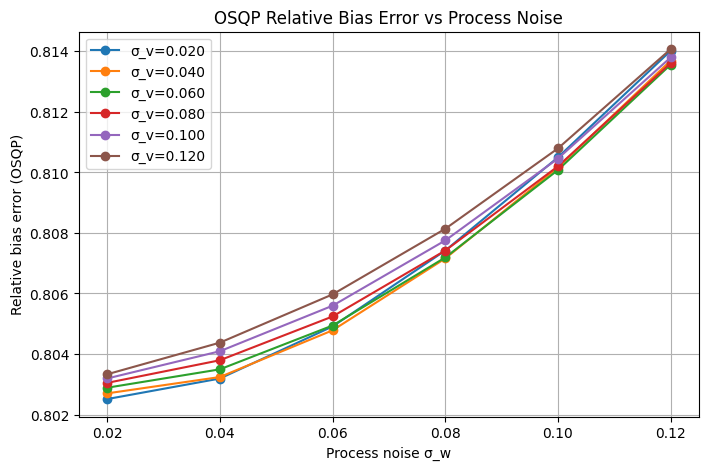

In [38]:
plot_bias_error_vs_noise()

Running OSQP SCP ...


C:\Users\Acer\AppData\Local\Temp\ipykernel_11580\1479149119.py:309: UserWarning: You are solving a parameterized problem that is not DPP. Because the problem is not DPP, subsequent solves will not be faster than the first one. For more information, see the documentation on Disciplined Parametrized Programming, at https://www.cvxpy.org/tutorial/dpp/index.html
  prob.solve(


CasADi not available -- skipping IPOPT.

Corrupted sensor indices : [7 9]
True  bias : [ 0.      0.      0.      0.      0.      0.      0.      3.8919  0.
 -5.1327]
OSQP  bias : [ 0.1087 -0.0929  0.0956  0.1275  0.0196  0.0288  0.0946  3.9365  0.5651
 -0.    ]

Relative state error:
  OSQP  : 164.0197

Relative bias error:
  OSQP  : 0.8025
Running OSQP SCP ...
CasADi not available -- skipping IPOPT.

Corrupted sensor indices : [7 9]
True  bias : [ 0.      0.      0.      0.      0.      0.      0.      3.8919  0.
 -5.1327]
OSQP  bias : [ 0.1052 -0.0958  0.1057  0.1389  0.0198  0.0319  0.1081  3.9305  0.5697
 -0.    ]

Relative state error:
  OSQP  : 148.3532

Relative bias error:
  OSQP  : 0.8027
Running OSQP SCP ...
CasADi not available -- skipping IPOPT.

Corrupted sensor indices : [7 9]
True  bias : [ 0.      0.      0.      0.      0.      0.      0.      3.8919  0.
 -5.1327]
OSQP  bias : [ 0.099  -0.1045  0.1142  0.149   0.0226  0.0362  0.1219  3.9237  0.5732
 -0.    ]

Relative 

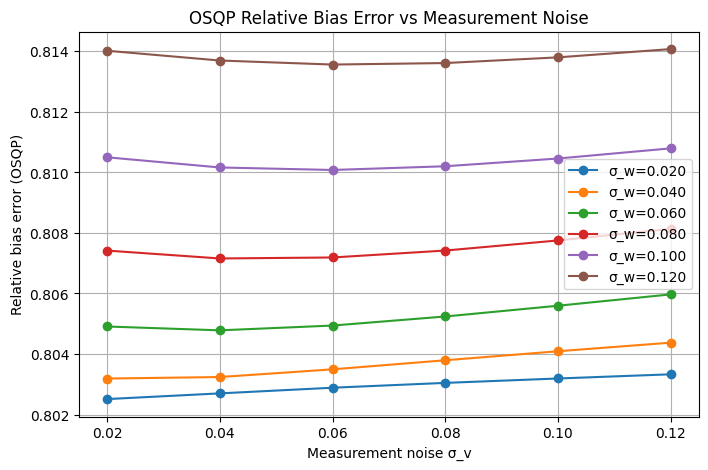

In [39]:
plot_bias_error_vs_measurement_noise()

In [6]:
np.linspace(0.0, 5.0, 26)

array([0. , 0.2, 0.4, 0.6, 0.8, 1. , 1.2, 1.4, 1.6, 1.8, 2. , 2.2, 2.4,
       2.6, 2.8, 3. , 3.2, 3.4, 3.6, 3.8, 4. , 4.2, 4.4, 4.6, 4.8, 5. ])

In [34]:
def plot_bias_error_vs_lambda():
    lambdas = np.logspace(-3.5, 2.5, 31)
    seeds = [3]

    errors = np.zeros(len(lambdas))

    for i, lam in enumerate(lambdas):
        err = 0

        for seed in seeds:
            result = run_comparison(
                seed=seed,
                T=50,
                sigma_w=0.01,
                sigma_v=0.01,
                s=2,
                n_links=20,
                p_meas=10,
                lam=lam,
                verbose=False,
                run_ipopt=False,
            )

            err += relative_error(
                result["b_true"],
                result["b_osqp"]
            )

        errors[i] = err / len(seeds)

    plt.figure(figsize=(8,5))
    plt.loglog(lambdas, errors, marker="o")
    plt.grid(True, which="both", ls="--")
    plt.xlabel("λ")
    plt.ylabel("Relative Bias Error")
    plt.title("OSQP Bias Error vs λ (averaged)")
    plt.show()

Running OSQP SCP ...


C:\Users\Acer\AppData\Local\Temp\ipykernel_11580\1479149119.py:309: UserWarning: You are solving a parameterized problem that is not DPP. Because the problem is not DPP, subsequent solves will not be faster than the first one. For more information, see the documentation on Disciplined Parametrized Programming, at https://www.cvxpy.org/tutorial/dpp/index.html
  prob.solve(
C:\Users\Acer\AppData\Local\Temp\ipykernel_11580\1479149119.py:309: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  prob.solve(


CasADi not available -- skipping IPOPT.

Corrupted sensor indices : [3 7]
True  bias : [0.     0.     0.     2.8267 0.     0.     0.     0.2783 0.     0.    ]
OSQP  bias : [-1.86000e-02 -7.05000e-02  7.90000e-02  2.88750e+00  2.18000e-02
 -1.98000e-02  1.64000e-02 -3.75300e-01 -5.05020e+00  4.45512e+01]

Relative state error:
  OSQP  : 422.5087

Relative bias error:
  OSQP  : 15.7874
Running OSQP SCP ...
CasADi not available -- skipping IPOPT.

Corrupted sensor indices : [3 7]
True  bias : [0.     0.     0.     2.8267 0.     0.     0.     0.2783 0.     0.    ]
OSQP  bias : [-0.0186 -0.0705  0.079   2.8876  0.0228 -0.0112  0.0899  0.2327 -0.2688
 -7.993 ]

Relative state error:
  OSQP  : 184.4798

Relative bias error:
  OSQP  : 2.8163
Running OSQP SCP ...
CasADi not available -- skipping IPOPT.

Corrupted sensor indices : [3 7]
True  bias : [0.     0.     0.     2.8267 0.     0.     0.     0.2783 0.     0.    ]
OSQP  bias : [-0.0186 -0.0705  0.079   2.8876  0.0229 -0.0103  0.0975  0.295

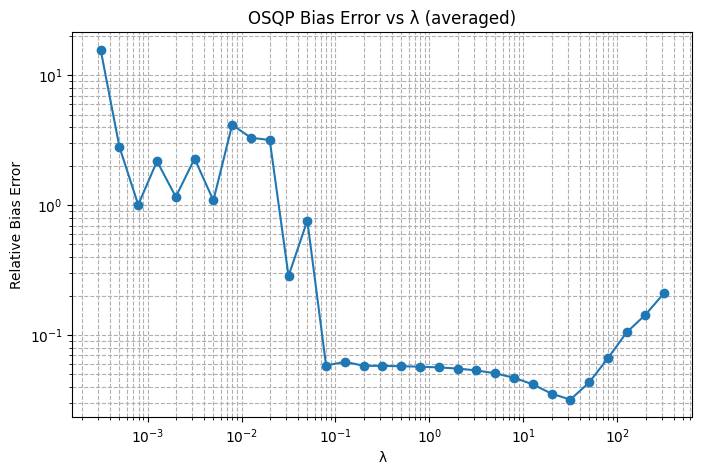

In [32]:
plot_bias_error_vs_lambda()

In [35]:
def plot_bias_error_vs_lambda_ipopt():
    lambdas = np.logspace(-3.5, 2.5, 31)
    seeds = [3]

    errors = np.zeros(len(lambdas))

    for i, lam in enumerate(lambdas):
        err = 0

        for seed in seeds:
            result = run_comparison(
                seed=seed,
                T=50,
                sigma_w=0.01,
                sigma_v=0.01,
                s=2,
                n_links=20,
                p_meas=10,
                lam=lam,
                verbose=False,
                run_ipopt=True,
            )

            err += relative_error(
                result["b_true"],
                result["b_ipopt"]
            )

        errors[i] = err / len(seeds)

    plt.figure(figsize=(8,5))
    plt.loglog(lambdas, errors, marker="o")
    plt.grid(True, which="both", ls="--")
    plt.xlabel("λ")
    plt.ylabel("Relative Bias Error")
    plt.title("IPOPT Bias Error vs λ (averaged)")
    plt.show()

Running OSQP SCP ...


C:\Users\Acer\AppData\Local\Temp\ipykernel_11580\1479149119.py:309: UserWarning: You are solving a parameterized problem that is not DPP. Because the problem is not DPP, subsequent solves will not be faster than the first one. For more information, see the documentation on Disciplined Parametrized Programming, at https://www.cvxpy.org/tutorial/dpp/index.html
  prob.solve(
C:\Users\Acer\AppData\Local\Temp\ipykernel_11580\1479149119.py:309: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  prob.solve(


Running IPOPT (warm-started from OSQP solution) ...

Corrupted sensor indices : [3 7]
True  bias : [0.     0.     0.     2.8267 0.     0.     0.     0.2783 0.     0.    ]
OSQP  bias : [-1.86000e-02 -7.05000e-02  7.90000e-02  2.88750e+00  2.18000e-02
 -1.98000e-02  1.64000e-02 -3.75300e-01 -5.05020e+00  4.45512e+01]
IPOPT bias : [-0.0186 -0.0706  0.0789  2.8865  0.0132 -0.0934 -0.6178 -5.1961 -5.351
  0.3977]

Relative state error:
  OSQP  : 422.5087
  IPOPT : 58.9958

Relative bias error:
  OSQP  : 15.7874
  IPOPT : 2.7081
Running OSQP SCP ...
Running IPOPT (warm-started from OSQP solution) ...

Corrupted sensor indices : [3 7]
True  bias : [0.     0.     0.     2.8267 0.     0.     0.     0.2783 0.     0.    ]
OSQP  bias : [-0.0186 -0.0705  0.079   2.8876  0.0228 -0.0112  0.0899  0.2327 -0.2688
 -7.993 ]
IPOPT bias : [-0.0186 -0.0705  0.079   2.8876  0.0227 -0.0119  0.0832  0.1776 -0.7288
 -5.4343]

Relative state error:
  OSQP  : 184.4798
  IPOPT : 48.1341

Relative bias error:
  OSQ

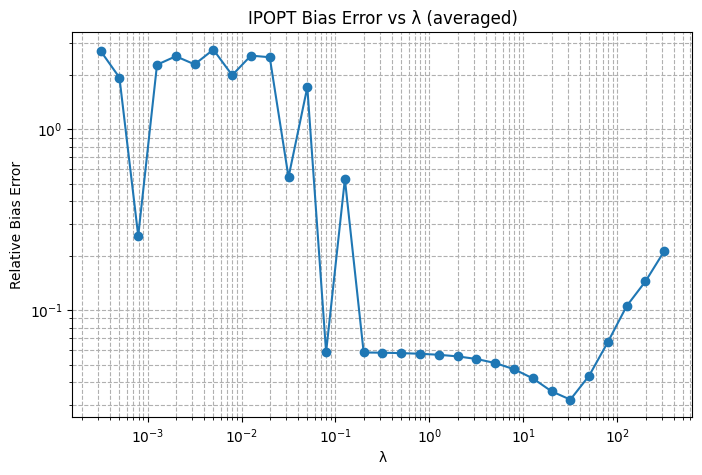

In [36]:
plot_bias_error_vs_lambda_ipopt()